# Remove Seasonality - part A

In the previous notebook we applied the differencing to remove the linear and the quadratic trend (by applying respectively one and two times the diff function on the time series). In this notebook, we will look at using the difference transform to remove seasonality.

There are many types of seasonality. Some obvious examples include; time of day, daily, weekly, monthly, annually, and so on. As such, identifying whether there is a seasonality component in your time series problem is subjective.

The simplest approach to determining if there is an aspect of seasonality is to plot and review your data, perhaps at different scales and with the addition of trend lines.

The example below applies the difference() function to a synthetic seasonal dataset. The dataset includes two cycles of 360 units each.

In [2]:
from math import radians, sin
from matplotlib import pyplot as plt

Let's create two functions that we will use, one that perform the difference (like the diff() function in Pandas) and one that performs the exact opposite transformation:

In [3]:
# create a differenced series
def difference(dataset, interval=1):
    diff = list()
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return diff

# invert differenced forecast
def inverse_difference(last_ob, value):
    return value + last_ob

Then we define a dataset with seasonality:

In [4]:
data = [sin(radians(i)) for i in range(360)] + [sin(radians(i)) for i in range(360)]

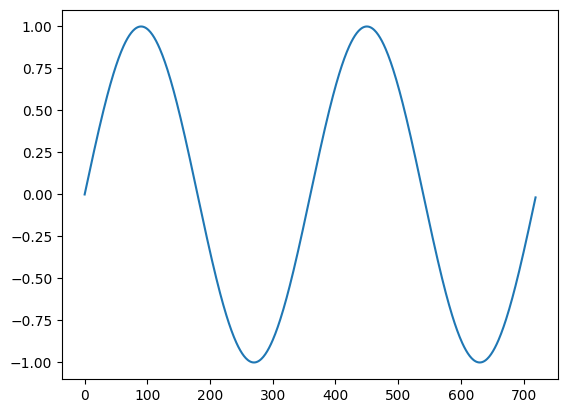

In [5]:
plt.plot(data)
plt.show()

Bein a sine function, this time series has clear cyclical peaks. In this case we already know the period, since we chosen it, and so we can perform the differencing in the same way as we did for detrending. What changes is only the period that we are using, indeed we want to **differencing the data using the period of seasonality**, in this case 360.

In [6]:
# difference the dataset
diff = difference(data, 360)

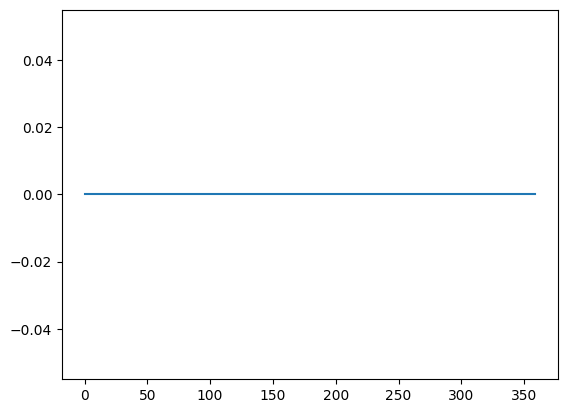

In [7]:
plt.plot(diff)
plt.show()

Being a synthetic data, the residuals after the seasonal difference is 0.

We can also apply the opposite transformation to get back our original data:

In [8]:
# invert the difference
inverted = [inverse_difference(data[i], diff[i]) for i in range(len(diff))]

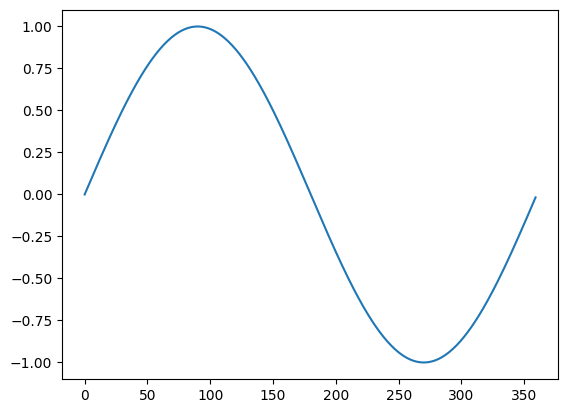

In [9]:
plt.plot(inverted)
plt.show()

# Remove Seasonality - part B

We can also remove seasonality by applying a centred-moving average. Let's see this approach applied to the Airline Passengers dataset.

Let's import first the libraries we need:

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# ingest the data
data_set = pd.read_csv('data/airline_passengers.csv',infer_datetime_format=True,parse_dates=["Month"])

/tmp/ipykernel_26988/4022013844.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data_set = pd.read_csv('data/airline_passengers.csv',infer_datetime_format=True,parse_dates=["Month"])


In [12]:
# add the column moy (i.e., month of year) and year to use later on to compute the seasonal component
data_set['moy'] = data_set["Month"].dt.month
data_set['year'] = data_set["Month"].dt.year 

In [13]:
# set the index
data_set.set_index("Month", inplace=True)

In [ ]:
# compute the centred moving average and the moving average
# They are just different in the way they deal with extrema
data_set['centred-MA'] = data_set['Thousands of Passengers'].rolling(window=12, center=True).mean()
data_set['MA'] = data_set['Thousands of Passengers'].rolling(window=12, center=False).mean()

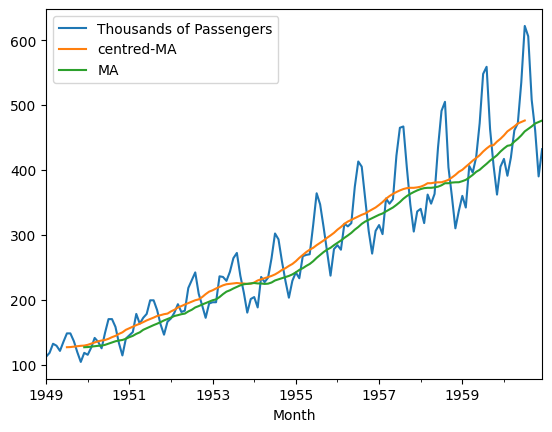

In [15]:
# visualize the original data and the two moving averages
data_set[["Thousands of Passengers","centred-MA","MA"]].plot()
plt.show()

## Additive removal

In [16]:
data_set['add_detrended'] = data_set['Thousands of Passengers']-data_set['centred-MA']

<Axes: xlabel='Month'>

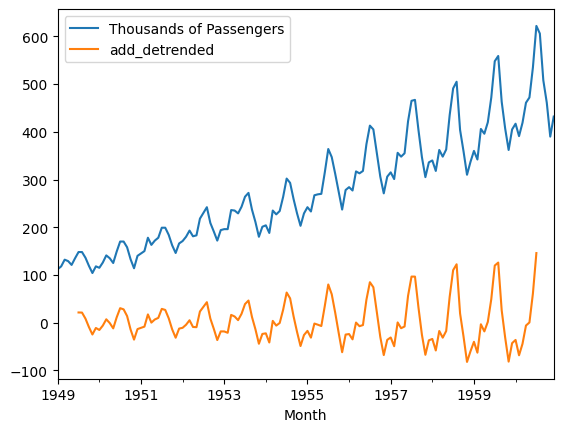

In [17]:
data_set[["Thousands of Passengers","add_detrended"]].plot()

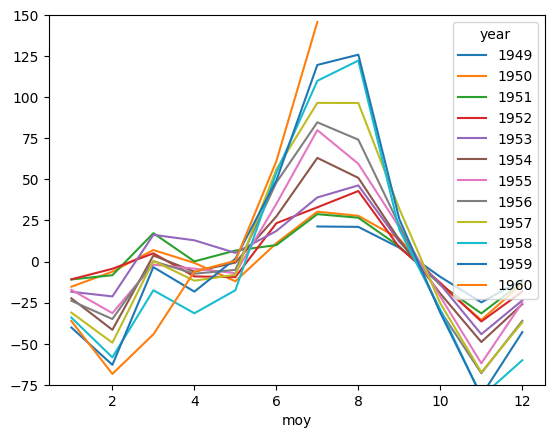

In [18]:
moys = data_set.pivot(index='moy', columns='year', values='add_detrended')
ax = moys.plot()
ax.set_ylim([-75,150])
plt.show()

Once we obtain the detrended time series, we group the data by the month of the year (moy) and compute the mean:

In [19]:
subsequence = data_set[["add_detrended","moy"]].groupby(["moy"]).mean()
subsequence.rename(columns={"add_detrended": "add_season"},inplace=True)

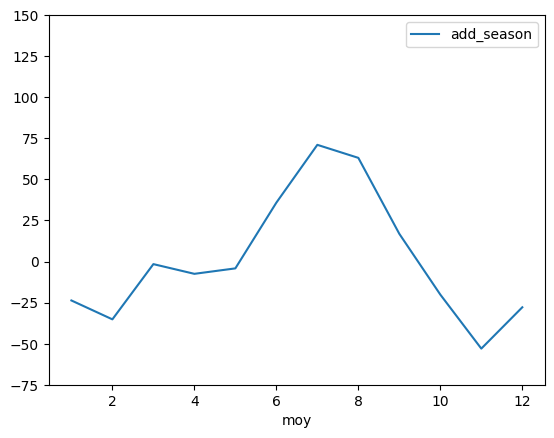

In [20]:
ax = subsequence.plot()
ax.set_ylim([-75,150])
plt.show()

In [21]:
mean = subsequence.mean()

In [22]:
subsequence["add_season"] = subsequence["add_season"]-float(mean)

/tmp/ipykernel_26988/2335513618.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  subsequence["add_season"] = subsequence["add_season"]-float(mean)


After obtaining one seasonal component, we create our seasonal time series by duplicating for the number of cycles present in the data (in this case 12):

In [23]:
seasonal_component = subsequence
for i in range(0,11):
    seasonal_component = pd.concat([seasonal_component,subsequence])
seasonal_component = seasonal_component.reset_index()

<Axes: >

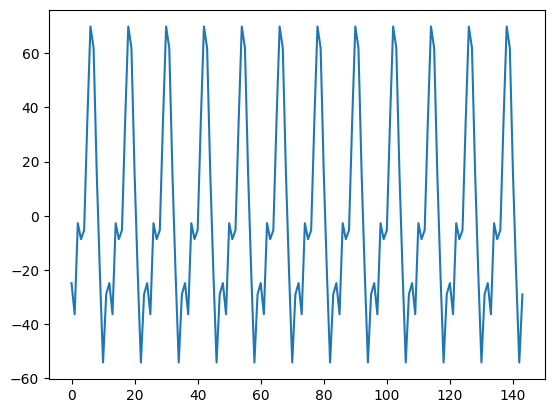

In [24]:
seasonal_component["add_season"].plot()

In [25]:
data_set['add_deseasoned'] = data_set['Thousands of Passengers'].values - seasonal_component["add_season"].values
data_set['add_deseasoned & add_detrended'] = data_set['add_detrended'].values - seasonal_component["add_season"].values

<Axes: xlabel='Month'>

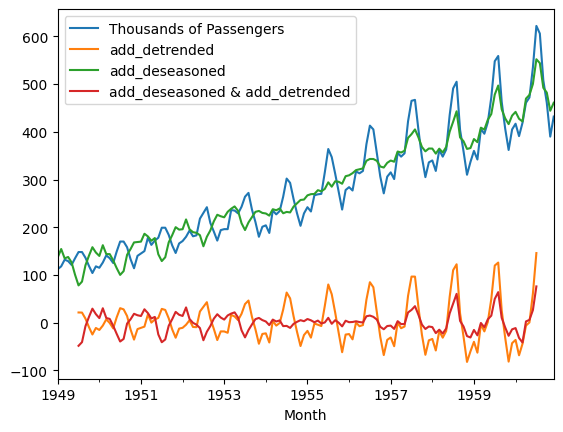

In [26]:
data_set[["Thousands of Passengers","add_detrended",'add_deseasoned','add_deseasoned & add_detrended']].plot()

<Axes: xlabel='Month'>

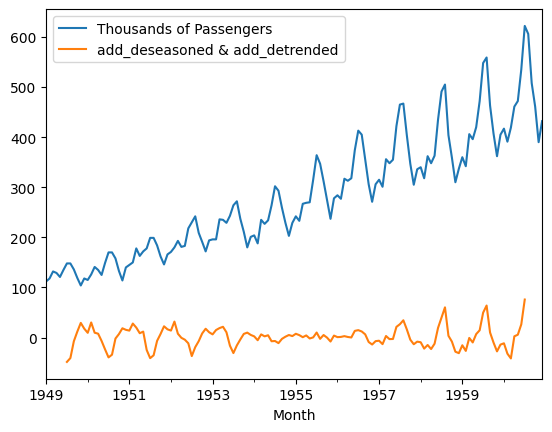

In [27]:
data_set[["Thousands of Passengers",'add_deseasoned & add_detrended']].plot()

## Multiplicative removal

In [28]:
data_set['mul_detrended'] = data_set['Thousands of Passengers']/data_set['centred-MA'] 

<Axes: xlabel='Month'>

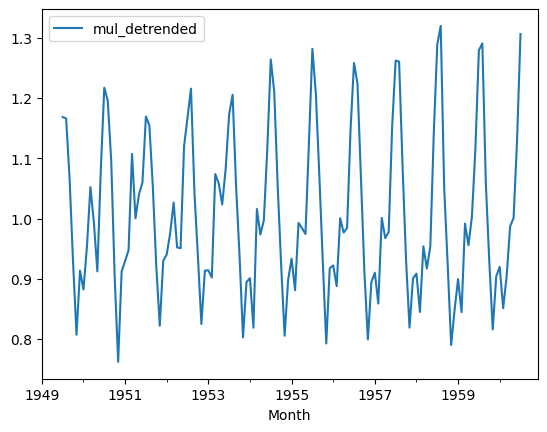

In [29]:
data_set[["mul_detrended"]].plot()

recall the shape of the additive modeling

<Axes: xlabel='Month'>

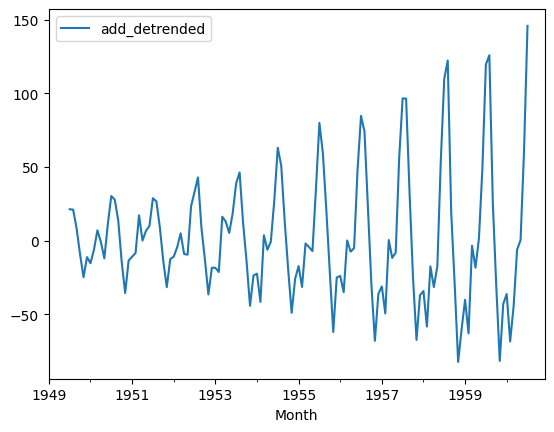

In [30]:
data_set[["add_detrended"]].plot() 

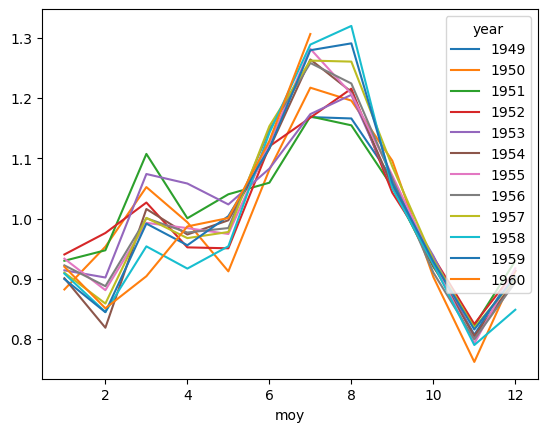

In [31]:
moys = data_set.pivot(index='moy', columns='year', values='mul_detrended')
ax = moys.plot()
plt.show()

**NOTE**: note the y scale! The additive model is in [-75,150], while the multiplicative is in [0.8,1.3]

Once we obtain the detrended time series, we group the data by the month of the year (moy) and compute the mean:

In [32]:
subsequence = data_set[["mul_detrended","moy"]].groupby(["moy"]).mean()
subsequence.rename(columns={"mul_detrended": "mul_season"},inplace=True)

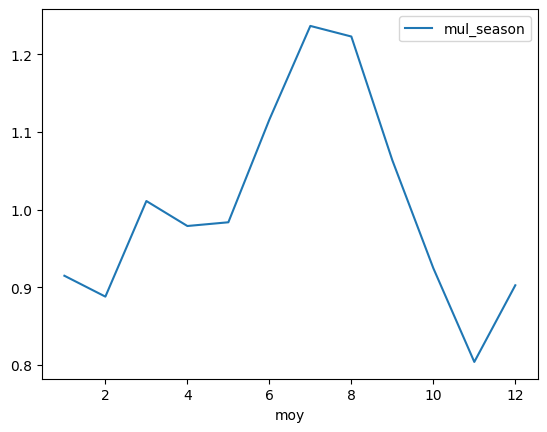

In [33]:
ax = subsequence.plot()
plt.show()

In [34]:
mean = subsequence.mean()

In [35]:
subsequence["mul_season"] = subsequence["mul_season"]/float(mean)

/tmp/ipykernel_26988/1613659217.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  subsequence["mul_season"] = subsequence["mul_season"]/float(mean)


After obtaining one seasonal component, we create our seasonal time series by duplicating for the number of cycles present in the data (in this case 12):

In [36]:
seasonal_component = subsequence
for i in range(0,11):
    seasonal_component = pd.concat([seasonal_component,subsequence])
seasonal_component = seasonal_component.reset_index()

<Axes: >

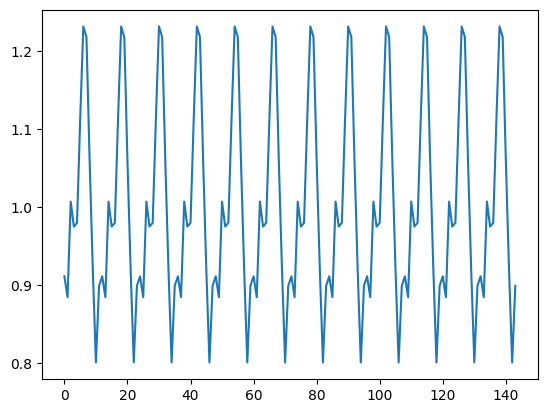

In [37]:
seasonal_component["mul_season"].plot()

In [38]:
data_set['mul_deseasoned'] = data_set['Thousands of Passengers'].values / seasonal_component["mul_season"].values
data_set['mul_deseasoned & mul_detrended'] = data_set['mul_detrended'].values / seasonal_component["mul_season"].values

<Axes: xlabel='Month'>

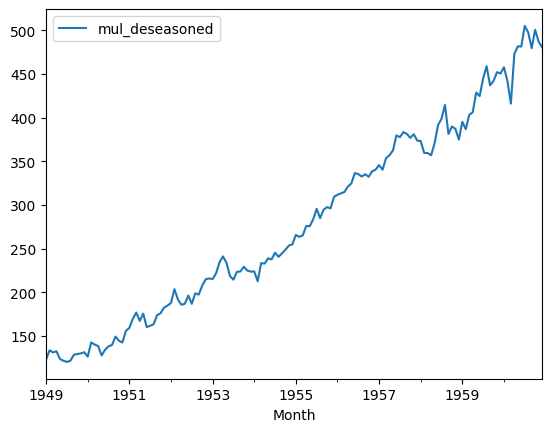

In [39]:
data_set[['mul_deseasoned']].plot()

<Axes: xlabel='Month'>

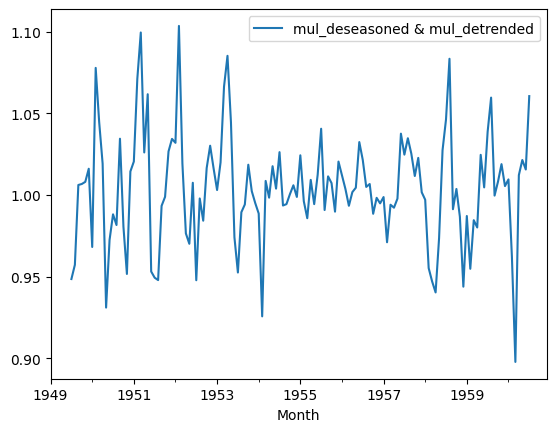

In [40]:
data_set[['mul_deseasoned & mul_detrended']].plot()